In [12]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, date_sub, current_date

In [3]:
!pip install plotly

     |████████████████████████████████| 9.9 MB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 359 kB 42.8 MB/s eta 0:00:01


In [13]:
# --- 1. SETUP SPARK (Same as app.py) ---
spark = (
    SparkSession.builder
    .appName("PlotPrototyping")
    .master("spark://spark-master:7077")
    .config("spark.cores.max", "1")
    .config("spark.executor.cores", "1")
    .enableHiveSupport()
    .config("hive.metastore.uris", "thrift://hive-metastore:9083") 
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
spark.sql("USE CryptoPredictions")

25/12/08 15:40:34 WARN HiveClientImpl: Detected HiveConf hive.execution.engine is 'tez' and will be reset to 'mr' to disable useless hive logic


DataFrame[]

In [41]:
print("Querying Hive...")
# Cast Datetime to string to avoid PyArrow compatibility issues
query = """
    SELECT 
        cast(Datetime as string) as Datetime_Str, 
                CurrentPrice,
                OpeningPrice,
                HighestDayPrice,
                LowestDayPrice,
                Symbol 
    FROM CryptocurrencySnapshot 
    ORDER BY Datetime DESC
"""
df_spark = spark.sql(query)
df = df_spark.toPandas()

# Explicit Type Conversion for cleaning
if not df.empty:
    # 1. Fix Date Format
    df['Datetime'] = pd.to_datetime(df['Datetime_Str'])
    
    # 2. Fix Numeric Price
    cols = ['CurrentPrice', 'OpeningPrice', 'HighestDayPrice', 'LowestDayPrice']
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    # 3. Clean Strings (Critical for filtering)
    df['Symbol'] = df['Symbol'].str.strip()
    
    df = df.sort_values("Datetime")
    print(f"✅ Loaded {len(df)} rows.")
    print("Assets found:", df['Symbol'].unique())
    display(df.head())
else:
    print("❌ No data found in Hive table.")

Querying Hive...


✅ Loaded 252728 rows.
Assets found: ['ETH' 'BTC' 'SOL']


,Datetime_Str,CurrentPrice,OpeningPrice,HighestDayPrice,LowestDayPrice,Symbol,Datetime
252727,2025-11-06 21:37:53,3321.82,3434.34,3456.46,3245.45,ETH,2025-11-06 21:37:53
252726,2025-11-06 21:37:53,100937.93,103619.65,104200.00,100300.95,BTC,2025-11-06 21:37:53
252725,2025-11-06 21:37:53,156.10,161.22,163.06,153.80,SOL,2025-11-06 21:37:53
252722,2025-11-06 21:38:12,100922.79,103606.18,104200.00,100300.95,BTC,2025-11-06 21:38:12
252724,2025-11-06 21:38:12,3321.18,3434.11,3456.46,3245.45,ETH,2025-11-06 21:38:12


In [10]:
df["Symbol"]

250615    ETH
250613    SOL
250614    BTC
250616    BTC
250617    SOL
         ... 
69676     SOL
69677     ETH
69679     SOL
69680     ETH
69678     BTC
Name: Symbol, Length: 252728, dtype: object

In [42]:
# --- 3. FILTERING (Simulate User Input) ---
selected_asset = "ETH" # Change this to test BTC, SOL
df_filtered = df[df['Symbol'] == selected_asset]

In [9]:
# A. Price Trend Chart
if not df_filtered.empty:
    fig = px.line(
        df_filtered, 
        x="Datetime", 
        y="CurrentPrice", 
        title=f"{selected_asset} Price Trend",
        template="plotly_white"
    )

    # LAYOUT & STYLING FIXES
    fig.update_layout(
        # 1. Clean Axis Titles
        xaxis_title="Date",
        yaxis_title="Price (USD)",
        
        # 2. Margins (Tighten them to fill the card)
        # l=left, r=right, t=top, b=bottom
        margin=dict(l=20, r=20, t=40, b=20),
        
        # 3. Hover Mode
        hovermode="x unified"
    )

    # 4. Date Formatting on Axis
    # Forces "Oct 12 14:00" format instead of raw timestamps
    fig.update_xaxes(
        tickformat="%b %d\n%H:%M",  
        nticks=10  # Limit number of ticks to avoid crowding
    )
    
    # 5. Price Formatting on Y-Axis
    fig.update_yaxes(
        tickprefix="$",
        tickformat=",.2f"
    )

    # 6. Line Style
    fig.update_traces(
        line=dict(width=2.5, color="#0d6efd"),
        hovertemplate="<b>Date:</b> %{x|%Y-%m-%d %H:%M}<br><b>Price:</b> $%{y:,.2f}<extra></extra>"
    )

    fig.show()
else:
    print("No data for selected asset.")

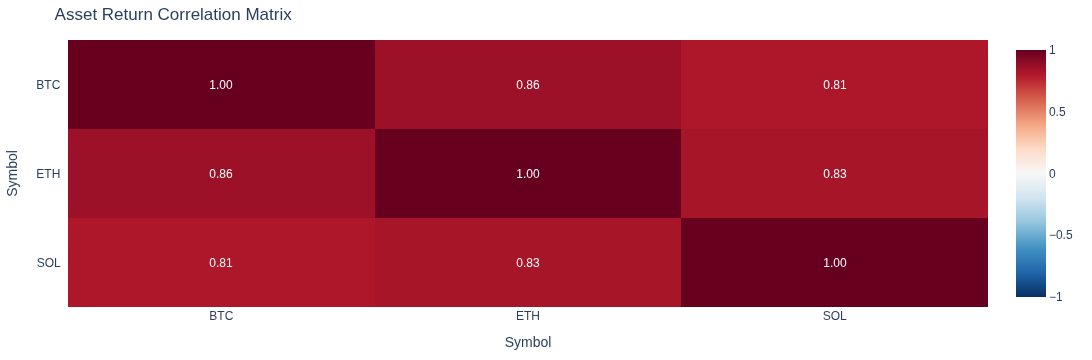

In [11]:
# 1. Pivot Data (One column per asset)
# aggfunc='mean' handles cases where multiple ticks exist for the same second
pivot_df = df.pivot_table(
    index='Datetime', 
    columns='Symbol', 
    values='CurrentPrice', 
    aggfunc='mean'
)

# 2. Calculate Percentage Returns
returns_df = pivot_df.pct_change().dropna()

# 3. Generate Heatmap
if not returns_df.empty:
    corr_matrix = returns_df.corr()
    
    fig_corr = px.imshow(
        corr_matrix,
        text_auto=".2f",
        aspect="auto",
        color_continuous_scale="RdBu_r", # Red to Blue
        zmin=-1, zmax=1,
        title="Asset Return Correlation Matrix"
    )
    fig_corr.update_layout(margin=dict(l=20, r=20, t=40, b=20))
    fig_corr.update_yaxes(ticksuffix = "  ")
    fig_corr.show()
else:
    print("Not enough overlapping data to calculate correlation.")

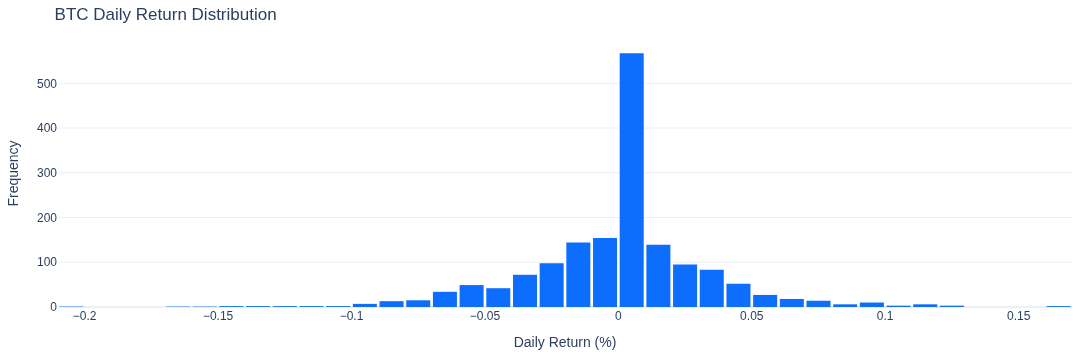

In [7]:
def plot_return_distribution(df, symbol):
    """
    Generates a Histogram of percentage returns for a specific asset.
    Args:
        df: Pandas DataFrame containing ['Datetime', 'Symbol', 'CurrentPrice']
        symbol: String (e.g., 'BTC', 'ETH')
    """
    # 1. Validation
    if df is None or df.empty:
        return _empty_plot("No Data Available")

    # 2. Filter for specific asset
    # We use .copy() to ensure we don't modify the original dataframe slice
    asset_df = df[df['Symbol'] == symbol].copy()
    
    if asset_df.empty:
        return _empty_plot(f"No Data found for {symbol}")

    # 3. Calculate Returns
    # Sorting is crucial for pct_change to work chronologically
    asset_df = asset_df.sort_values("Datetime")
    asset_df['Return'] = asset_df['CurrentPrice'].pct_change() * 100
    
    # Drop the first row (NaN) created by pct_change
    asset_df = asset_df.dropna()

    # 4. Generate Plot
    fig = px.histogram(
        asset_df, 
        x="Return", 
        nbins=50,
        title=f"{symbol} Daily Return Distribution",
        template="plotly_white",
        color_discrete_sequence=["#0d6efd"] # Bootstrap Blue to match theme
    )

    # 5. Styling
    fig.update_layout(
        xaxis_title="Daily Return (%)",
        yaxis_title="Frequency",
        margin=dict(l=20, r=20, t=40, b=20),
        bargap=0.1, # Gap between bars
        hovermode="x"
    )
    
    return fig

plot_return_distribution(df, "BTC")

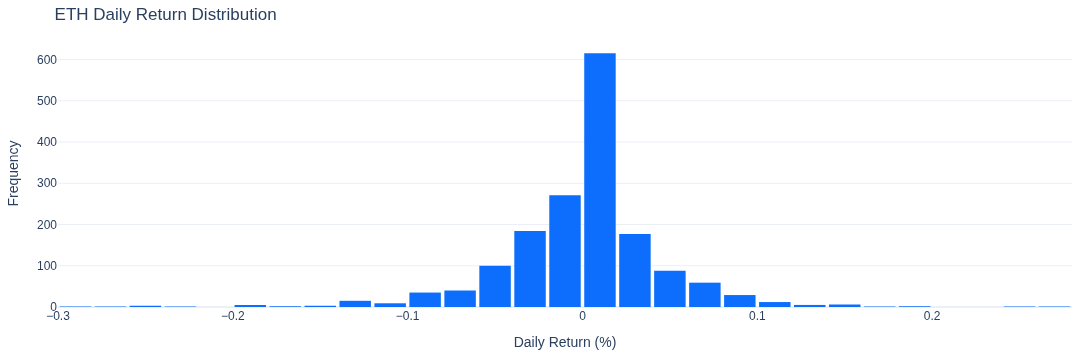

In [8]:
plot_return_distribution(df, "ETH")

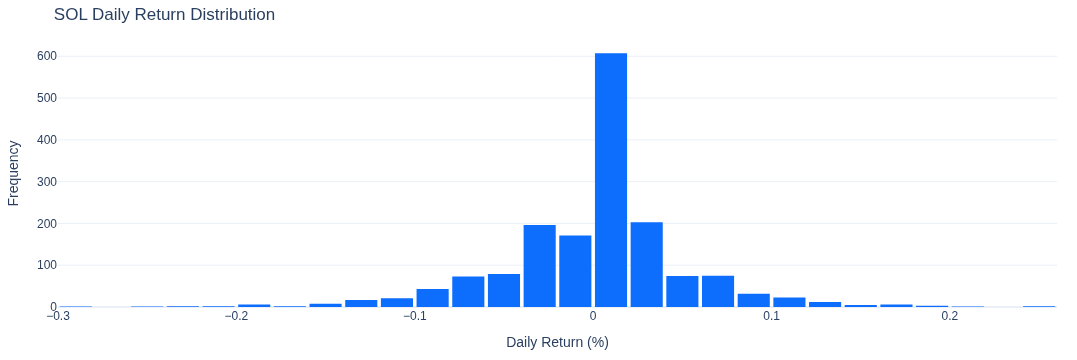

In [9]:
plot_return_distribution(df, "SOL")

In [10]:
spark.stop()
print("Spark Session Stopped")

Spark Session Stopped


In [55]:
df_filtered['SMA7'] = df_filtered['CurrentPrice'].rolling(window=20, min_periods=1).mean()  # Approx window for minutes
df_filtered['SMA30'] = df_filtered['CurrentPrice'].rolling(window=50, min_periods=1).mean()

In [56]:
df_filtered = df_filtered.set_index("Datetime").resample("1H").agg({
    "OpeningPrice": "first",
    "HighestDayPrice": "max",
    "LowestDayPrice": "min",
    "CurrentPrice": "last"
}).dropna().reset_index()

df_filtered['SMA7'] = df_filtered['CurrentPrice'].rolling(window=7 * 24 * 60, min_periods=1).mean()
df_filtered['SMA30'] = df_filtered['CurrentPrice'].rolling(window=30 * 24 * 60, min_periods=1).mean()


In [57]:
def price_chart_view(df, indicators):

    # Base: Candlestick
    fig = go.Figure(data=[go.Candlestick(
        x=df['Datetime'],
        open=df['OpeningPrice'],
        high=df['HighestDayPrice'],
        low=df['LowestDayPrice'],
        close=df['CurrentPrice'],
        name=selected_asset
    )])

    # Overlay: Moving Averages (If selected)
    indicators = indicators
    if "SMA7" in indicators:
        fig.add_trace(go.Scatter(x=df['Datetime'], y=df['SMA7'], mode='lines', name='SMA 7',
                                 line=dict(color='orange', width=1.5)))
    if "SMA30" in indicators:
        fig.add_trace(go.Scatter(x=df['Datetime'], y=df['SMA30'], mode='lines', name='SMA 30',
                                 line=dict(color='purple', width=1.5)))

    # Layout
    fig.update_layout(
        title=dict(text=f"{selected_asset} Price Action", x=0.01),
        yaxis_title="Price (USD)",
        margin=dict(l=60, r=20, t=40, b=40),  # Increased bottom margin for rangeslider
        hovermode="x unified",
        height=500,
        xaxis_rangeslider_visible=False,  # Hide the mini-slider to save space
        xaxis=dict(type='date'),
        template="plotly_white"
    )
    fig.update_xaxes(tickformat="%b %d %H:%M")
    fig.update_yaxes(tickprefix="$")

    fig.show()

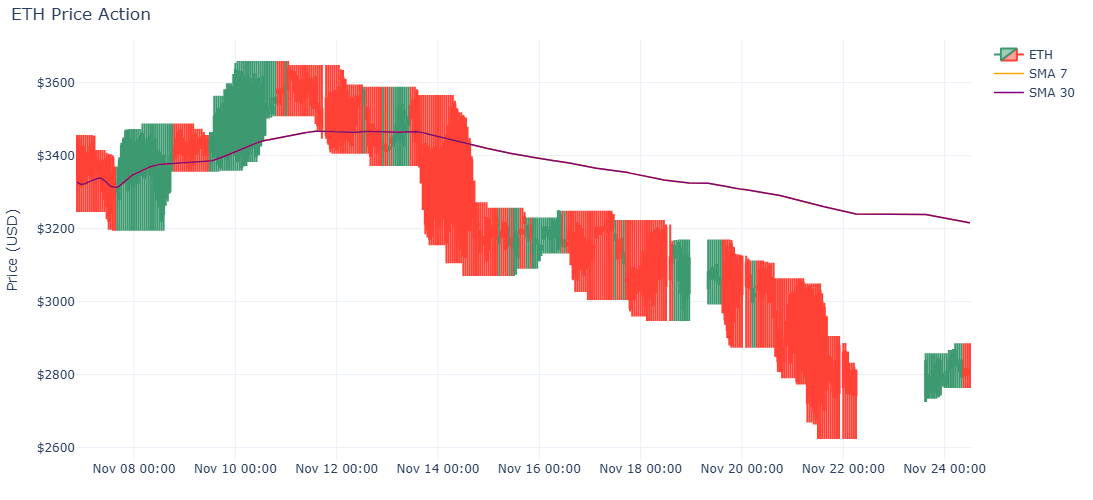

In [58]:
price_chart_view(df_filtered, ["SMA7", "SMA30"])

In [40]:
df

,Datetime,OpeningPrice,HighestDayPrice,LowestDayPrice,CurrentPrice,SMA7
0,2025-11-06 21:00:00,3434.34,104200.00,153.80,3326.86,NaN
1,2025-11-06 22:00:00,3443.50,104200.00,153.80,155.73,NaN
2,2025-11-06 23:00:00,162.89,104200.00,153.45,101346.03,NaN
3,2025-11-07 00:00:00,103856.24,104200.00,153.45,156.76,NaN
4,2025-11-07 01:00:00,3405.06,104200.00,153.45,3323.73,NaN
...,...,...,...,...,...,...
376,2025-11-24 08:00:00,128.89,88127.64,128.83,2838.51,29904.773333
377,2025-11-24 09:00:00,86137.18,88127.64,128.44,2797.71,26474.724583
378,2025-11-24 10:00:00,86393.03,88127.64,128.44,129.25,26474.788333
379,2025-11-24 11:00:00,2808.72,88127.64,128.44,2803.06,26586.284583
